# Notebook 02: Exploratory Data Analysis & Statistical Validation

This notebook focuses on the rigorous statistical validation and geometric inspection of our engineered features. Our goal is not merely descriptive, but diagnostic: we must test the probability distributions and vector spaces constructed in the previous phase to ensure they are mathematically sound for distance-based recommendation algorithms.

### Objectives:
* **Distributional Analysis (PDF/CDF):** Evaluating the probability density and cumulative distribution of the $S_{final}$ metric to quantify structural biases (e.g., skewness, kurtosis) and deviations from normality.
* **Information Sparsity & Entropy:** Measuring the informational density of the multi-dimensional feature matrix using Shannon entropy to isolate variables lacking true discriminative power.
* **Multicollinearity Detection (VIF):** Identifying linearly dependent vectors within the metadata space that would artificially inflate variance and distort similarity calculations.
* **Dimensionality Reduction:** Projecting the high-dimensional semantic embeddings into a lower-dimensional manifold to empirically validate the geometric coherence of the NLP clusters.

In [1]:
from src.bookj_two_utils import *
reviews_df, content_matrix = load_eda_assets()
s_final = get_score_series(reviews_df)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading assets from '../data/processed' …
All assets loaded. System ready.


## 2. Probability Density and Signal Quality of $S_{final}$

Before calculating multidimensional distances between movies, we must interrogate our primary metric of cinematic quality: the Hybrid Sentiment Index ($S_{final}$). In this section, we visualize the empirical distribution of the scores by overlaying a Histogram, a Kernel Density Estimate (KDE), and a theoretical Normal (Gaussian) fit.

The objective is not just to see "what scores are most common," but to evaluate the structural integrity and the probabilistic behavior of the data we engineered in Notebook 01.

### Formulating the Hypotheses
We approach this visual inspection with three specific statistical questions in mind:

1.  **Continuity vs. Discretization:** Does our normalization process yield a truly continuous probability density, or are we dealing with artificial quantization? If the data is highly discrete, density estimators like KDE might produce misleading visual artifacts.
2.  **Critic Bias (Skewness):** Assuming cinematic quality is objective, the scores should theoretically form a symmetric bell curve. However, do critics exhibit a systematic bias? We hypothesize that professional reviews might skew negatively (a long tail of terrible movies) while clustering heavily around a "safe" above-average rating.
3.  **Parametric Viability:** Can we rely on similarity algorithms that implicitly assume normality (Gaussian distribution)? If the empirical data deviates too severely from the green theoretical fit, any parametric statistical inference we attempt later will be mathematically invalid.

The outcome of this plot will dictate exactly how much "trust" our recommendation engine can place in the raw value of $S_{final}$ compared to the latent semantic features.

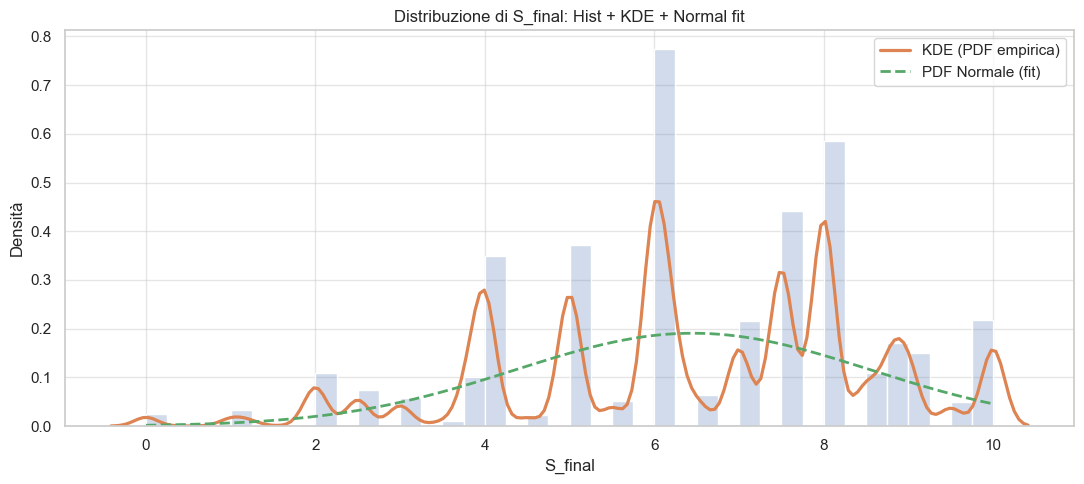

In [2]:
plot_pdf_distribution(s_final)

### 2.1 Visual Diagnostics: Analyzing the PDF Output

The empirical observation of the Probability Density Function (Hist + KDE) against the theoretical Normal fit yields immediate, unambiguous answers to our initial hypotheses. The visual evidence reveals severe structural anomalies in the $S_{final}$ vector space.

#### 1. Rejection of Continuity (Quantization Artifacts)
The empirical KDE (orange line) oscillates violently, failing to form a smooth continuous curve. Instead, we observe stark, isolated peaks aligning perfectly with integer values (4.0, 5.0, 6.0, 7.0, 8.0). This confirms that $S_{final}$, despite our normalization efforts, behaves mathematically as a **discrete, quantized ordinal variable**. The deep "valleys" between these integers (e.g., between 6.0 and 7.0) are merely interpolation artifacts of the Kernel Density Estimator attempting to smooth over empty continuous space.

#### 2. The "Safe Score" Bias and Negative Skewness
The distribution drastically violates symmetry. While the theoretical Gaussian fit (green dashed line) attempts to center the data, the actual empirical mass is heavily concentrated on the right side of the domain.
The most glaring feature is the towering, dominant mode exactly at **6.0**. This visually confirms a systemic "Critic Bias": reviewers disproportionately assign a safe, passing grade to mediocre films, creating a massive density cluster. Conversely, there is a long, sparse tail dragging to the left (scores 0-4), indicating a reluctance to assign extremely low scores.

#### 3. Failure of the Parametric Assumption
The theoretical Normal fit completely fails to capture the true geometry of the data. The empirical distribution is multimodal and heavily skewed.
**Architectural Consequence:** Because the data definitively rejects the assumption of normality, relying on purely parametric similarity metrics (like standard unweighted Euclidean distance) for $S_{final}$ will mathematically handicap the recommendation engine. The system will suffer from "resolution failure" in the 6.0 - 8.0 range, struggling to mathematically distinguish between a mediocre film and a great one due to the inflated density in that specific vector space.

---

*Note: Visual diagnostics strongly suggest a departure from normality, but robust statistical architecture requires quantitative proof. In the next subsection, we will analyze the Empirical Cumulative Distribution Function (ECDF) and calculate the exact statistical moments (Skewness, Kurtosis, Shapiro-Wilk) to mathematically formalize these visual observations.*

### 2.2 Quantitative Validation: ECDF and Statistical Moments

Visual density estimations can be misleading when applied to quantized data. To rigorously validate the structural integrity of our $S_{final}$ metric, we must shift from visual density to exact cumulative probability.

In this section, we compute the **Empirical Cumulative Distribution Function (ECDF)** alongside the exact statistical moments (Skewness, Kurtosis) and normality tests (Shapiro-Wilk, Kolmogorov-Smirnov) to mathematically formalize the anomalies observed in the previous density plots.

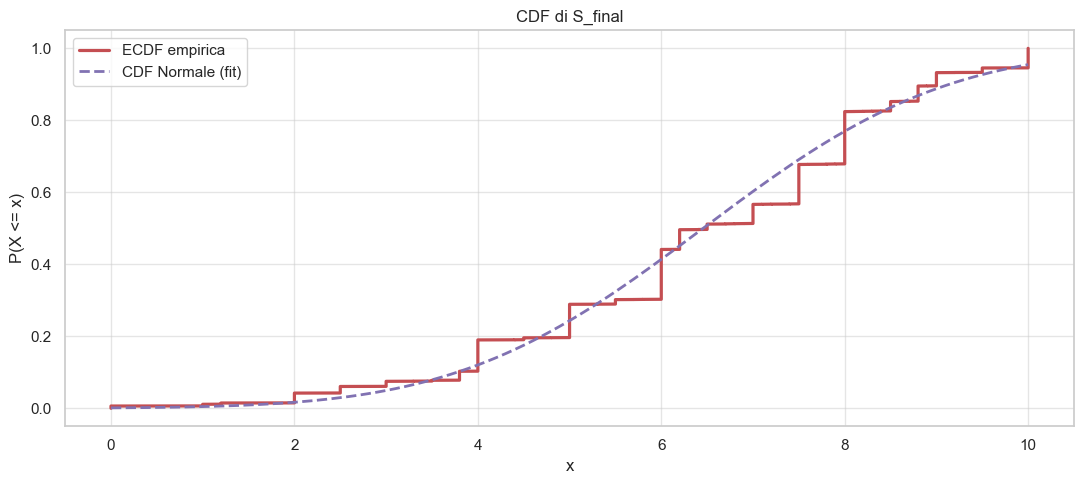

,metric,value
0,mean,6.456192e+00
1,variance,4.382631e+00
2,skewness,-4.882723e-01
3,kurtosis_excess,-1.684203e-01
4,kurtosis_pearson,2.831580e+00
5,shapiro_p_value,2.368069e-33
6,ks_p_value,6.007848e-64


,metric,value
0,P(S_final <= 6.0),0.441152


In [3]:
plot_cdf_distribution(s_final)
moments_table = compute_statistical_moments(s_final)
display(moments_table)
suff_prob = compute_sufficiency_probability(s_final)
display(suff_prob)

#### Statistical Proof and Architectural Implications

The quantitative outputs strictly confirm the structural anomalies hypothesized during the visual diagnostics:

1.  **The "Staircase" ECDF:** The empirical cumulative distribution (red line) completely ignores the smooth theoretical Normal CDF. Instead, it forms rigid, vertical "steps" precisely at integer values (e.g., 4.0, 5.0, 6.0, 7.0, 8.0). This provides mathematical proof that $S_{final}$ behaves as a highly quantized ordinal scale, inherently unsuited for continuous probability models.
2.  **Rejection of the Null Hypothesis ($H_0$):** The normality test p-values are functionally zero (Shapiro-Wilk $p \approx 2.37 \times 10^{-33}$, Kolmogorov-Smirnov $p \approx 6.01 \times 10^{-64}$). The hypothesis that our data is normally distributed is categorically rejected. The distribution is demonstrably discrete and asymmetrical, invalidating the use of unweighted parametric similarity metrics.
3.  **Skewness and The Resolution Bottleneck:** The negative skewness ($-0.488$) confirms a systemic "Critic Bias" toward positive ratings. However, the most critical architectural constraint is found in the cumulative probability: $P(S_{final} \le 6.0) \approx 0.4412$. Because only ~44% of the dataset falls at or below a 6.0, a massive ** ~56% of all movies are compressed into just four integer values (7, 8, 9, 10)**.

**Conclusion for the Recommendation Engine:** If the system relies too heavily on $S_{final}$ to compute similarity, it will suffer from severe "score inflation," rendering it mathematically unable to distinguish between a "good" movie (7) and a "masterpiece" (9) due to extreme vector crowding. To establish true mathematical distance, the algorithm must strongly rely on our multi-dimensional features (Metadata and Semantic Embeddings) to break the ties created by this scoring bottleneck.

## 3. Vector Space Integrity: Sparsity and Shannon Entropy

Moving from the target variable ($S_{final}$) to the independent feature space, we must analyze the structural integrity of the `content_matrix`. This matrix is a hybrid multidimensional space containing both dense semantic embeddings (SBERT) and sparse categorical metadata (Genres, Directors).

Before applying distance metrics like Cosine Similarity, we must evaluate the mathematical "usefulness" of our dimensions. A matrix overloaded with zero-variance features will suffer from the **Curse of Dimensionality**, rendering distance calculations meaningless.

### 3.1 Mathematical Framework

We evaluate the feature space using two metrics:

1.  **Matrix Sparsity ($S$):** Defines the ratio of zero-valued elements to total elements.
    $$S = 1 - \frac{\text{NNZ}}{N \times M}$$
    Where NNZ is the number of Non-Zero elements. A highly sparse matrix ($S \to 1$) mathematically mandates the use of angle-based similarity (Cosine) rather than magnitude-based similarity (Euclidean).
2.  **Shannon Entropy ($H$):** Measures the expected information content of each binary metadata feature. For a binary feature with presence probability $p$, the entropy is:
    $$H = - (p \log_2 p + (1-p) \log_2 (1-p))$$
    Features with $p \approx 0$ or $p \approx 1$ have entropy near $0$, meaning they provide almost zero global discriminative power. Features with $p \approx 0.5$ maximize entropy ($H = 1$), splitting the dataset evenly and providing maximum information gain.



By analyzing the entropy distribution, we can mathematically identify "noise" features (e.g., a highly obscure director with only two movies) that expand the matrix dimensionality without contributing meaningful structural variance to the recommendation system.

Matrice shape: (17712, 2284)
Elementi non nulli: 6851546
Sparsity S: 0.830635

Feature a bassa entropia (meno discriminanti):
     feature  p_presence       entropy
2274     374         1.0  1.056886e-11
2233     333         1.0  1.056886e-11
2234     334         1.0  1.056886e-11
2235     335         1.0  1.056886e-11
2236     336         1.0  1.056886e-11
2237     337         1.0  1.056886e-11
2238     338         1.0  1.056886e-11
2239     339         1.0  1.056886e-11
2240     340         1.0  1.056886e-11
2241     341         1.0  1.056886e-11
2242     342         1.0  1.056886e-11
2243     343         1.0  1.056886e-11
2244     344         1.0  1.056886e-11
2245     345         1.0  1.056886e-11
2272     372         1.0  1.056886e-11
2277     377         1.0  1.056886e-11
2276     376         1.0  1.056886e-11
2247     347         1.0  1.056886e-11
2248     348         1.0  1.056886e-11
2249     349         1.0  1.056886e-11


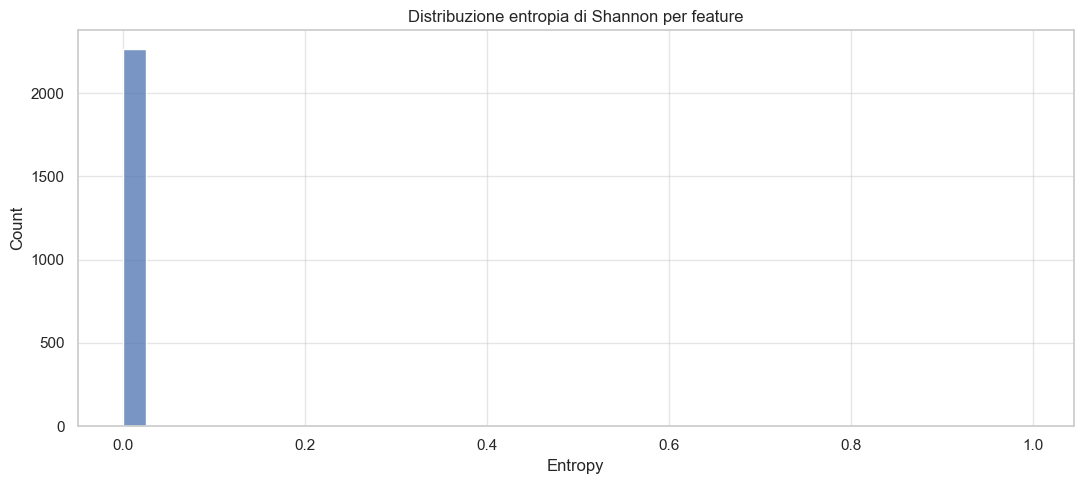

In [4]:
entropy_df = analyze_sparsity_and_entropy(content_matrix)

### 3.2 Diagnostic Results: The Zero-Entropy Collapse

The empirical evaluation of Shannon Entropy across the `content_matrix` reveals a massive collapse at $H \approx 0$. Rather than indicating a flawed dataset, this histogram perfectly diagnoses the extreme topological duality of our hybrid feature space.

The near-zero entropy originates from two mathematically distinct phenomena:

1.  **Dense Embedding Saturation ($p \to 1.0$):** The tabular output highlights numerical features (e.g., indices 333-377) with a presence probability of 1.0. These represent the 384 continuous dimensions of the SBERT semantic embeddings. Because every movie possesses a plot embedding, the binary presence of these features is constant across the dataset, resulting in an expected binary entropy of functionally zero. Their informational value lies strictly in continuous variance, not categorical presence.
2.  **Hyper-Sparse Metadata ($p \to 0.0$):** The vast majority of the remaining 2,000+ dimensions (predominantly Directors) fall into the long-tail distribution. A director associated with only 3 out of 10,000 movies has a presence probability of $p = 0.0003$. The Shannon entropy for such sparse vectors asymptotically approaches zero.

**Architectural Implications:** The feature matrix is heavily dominated by categorical features that provide massive local discriminative power (e.g., matching two movies by a rare director) but almost zero global variance.
This structural extreme strictly prohibits the use of magnitude-sensitive distance metrics (like Euclidean or Manhattan distance). The recommendation logic **must** employ **Cosine Similarity** to compute angular distances, effectively bypassing the curse of dimensionality caused by thousands of shared zero-values.

## 4. Structural Redundancy: Correlation and Variance Inflation Factor (VIF)

Having established the sparsity profile of our vector space, we must now test for linear dependence among our categorical metadata (Genres and Directors). In a distance-based recommendation engine, assuming feature independence is a critical architectural requirement.

### 4.1 The Danger of Multicollinearity
If two features are highly correlated (e.g., the genres "Kids & Family" and "Animation"), they provide mathematically redundant information. In a Cosine Similarity calculation, these redundant vectors will artificially inflate the proximity between two movies. Essentially, the algorithm will "double-count" the weight of that concept, distorting the intended geometric balance ($w_g$) of the `content_matrix`.



### 4.2 Mathematical Framework

To diagnose this redundancy, we deploy two metrics on the most frequent categorical features:
1.  **Correlation Matrices (Pearson & Spearman):** Since we are evaluating binary presence variables, the Pearson correlation mathematically equates to the $\phi$ (phi) coefficient. It measures the strict co-occurrence rate between two dimensions.
2.  **Variance Inflation Factor (VIF):** A rigorous quantitative threshold for multicollinearity. It is calculated by regressing each categorical feature $X_i$ against all other features in the subset:
    $$VIF_i = \frac{1}{1 - R_i^2}$$
    Where $R_i^2$ is the coefficient of determination for that regression.



* $VIF = 1$: Complete orthogonal independence.
* $1 < VIF < 5$: Moderate, acceptable correlation.
* $VIF \ge 5$: Critical multicollinearity. The feature's geometric weight is dangerously inflated by its peers.

If we observe VIF values exceeding our threshold ($\ge 5.0$), it provides empirical proof that our categorical space contains redundant dimensions that may skew the similarity search.

### 4.3 Bivariate Correlation: Pearson and Spearman Heatmaps

Before aggregating the multicollinearity into a single VIF score, we must visually inspect the pairwise interactions between our categorical dimensions.

Given that our metadata (Genres) is strictly binary (presence/absence), we deploy two correlation metrics:
1.  **Pearson Correlation:** On binary data, this is mathematically equivalent to the **$\phi$ (phi) coefficient**. It measures the strict linear co-occurrence of two features across the dataset.
2.  **Spearman Rank Correlation:** Evaluates monotonic relationships. While typically used for continuous ordinal data, applying it here helps verify if the linear co-occurrences detected by Pearson are robust against severe distributional imbalances (e.g., extremely rare genres vs. highly common ones).

Our objective is to scan the off-diagonal elements for high positive values (red/warm squares), which would indicate that two distinct tags are systematically applied to the exact same movies, threatening our vector space with redundancy.

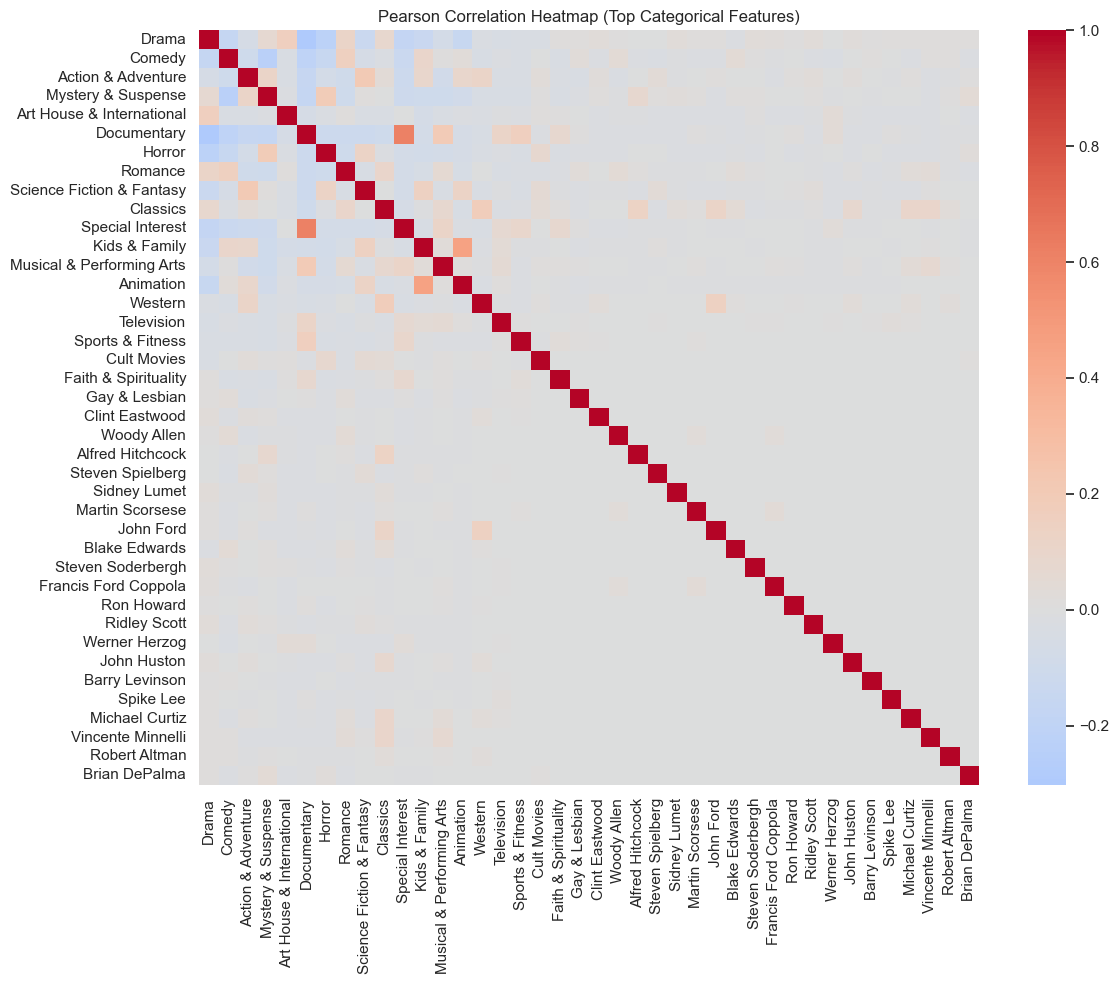

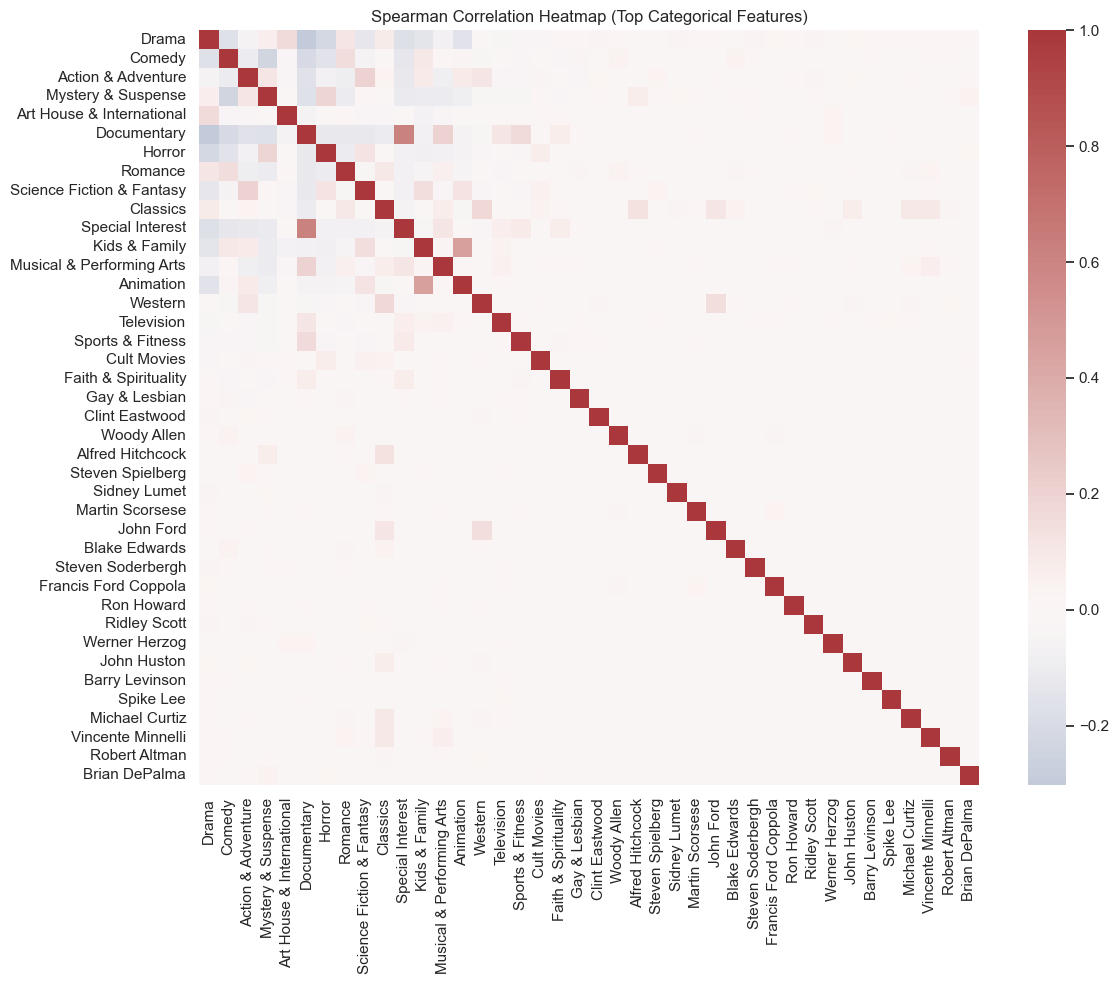

In [5]:
plot_pearson_correlation(content_matrix)
plot_spearman_correlation(content_matrix)

### 4.3.1 Bivariate Diagnostics: Heatmap Autopsy

The visual inspection of the pairwise correlation matrices (Pearson and Spearman) confirms the structural integrity of our categorical metadata, aligning seamlessly with the theoretical requirements of a vector space model.

#### Key Empirical Observations:

1.  **Global Orthogonality:** The vast majority of the off-diagonal elements in both matrices cluster tightly around $0.0$ (neutral gray). This indicates that the assignment of most tags is statistically independent. This global orthogonality is crucial; it guarantees that the Cosine Similarity calculation will not be systematically biased by redundant dimensions.
2.  **Expected Semantic Clusters (Positive Correlation):** We observe isolated "warm spots" (positive correlation $\approx 0.4 - 0.6$) representing structural industry overlaps:
    * `Animation` and `Kids & Family`
    * `Documentary` and `Special Interest`
    * `Action & Adventure` and `Science Fiction & Fantasy`
    These overlaps are logical and expected. However, because they do not reach deep red (correlation $> 0.8$), they represent distinct sub-spaces rather than duplicated concepts.
3.  **Mutual Exclusivity (Negative Correlation):** The Pearson matrix reveals pale blue squares (negative correlation) between macro-genres such as `Drama` and `Comedy`, or `Drama` and `Documentary`. This proves that the metadata accurately reflects the mutually exclusive nature of certain cinematic categories.

**Architectural Takeaway:** The visual pairwise relationships show no evidence of severe, pathological multicollinearity. The sparse semantic clusters observed here set the perfect foundation for the quantitative Variance Inflation Factor (VIF) calculation in the next step.

### 4.4 Quantitative Validation: Variance Inflation Factor (VIF)

While pairwise correlation heatmaps provide excellent visual diagnostics for binary co-occurrences, they suffer from a critical mathematical blind spot: they cannot detect multi-variable collinearity. A specific genre might not be highly correlated with any single dimension individually, but it could still be a perfect linear combination of several other metadata dimensions combined.

To rigorously guarantee the orthogonal independence of our feature space, we must transition from bivariate to multivariate diagnostics. We compute the **Variance Inflation Factor (VIF)** by regressing each categorical feature against the entire subset of remaining features.

The objective is strictly threshold-based:
* We are scanning for any dimension that breaches the **$VIF \ge 5.0$** critical limit.
* Any feature crossing this threshold mathematically proves that its vector space is redundant, meaning its weight in the final Cosine Similarity calculation would be artificially inflated, distorting the recommender's geometric accuracy.

We now execute the VIF computation to extract the definitive mathematical verdict.

,feature,VIF
5,Documentary,2.209770
10,Special Interest,1.613122
0,Drama,1.508781
1,Comedy,1.366143
11,Kids & Family,1.329978
13,Animation,1.305846
6,Horror,1.286607
3,Mystery & Suspense,1.190607
2,Action & Adventure,1.175443
8,Science Fiction & Fantasy,1.123148


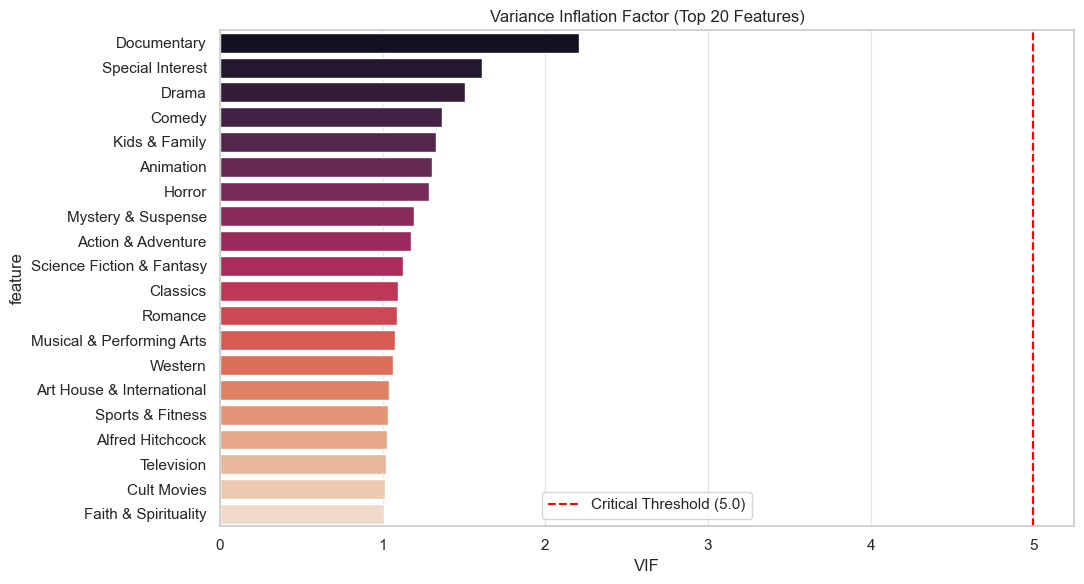

In [6]:
vif_df = compute_vif_metrics(content_matrix)
display(vif_df.head(10))
plot_vif_distribution(vif_df)

### 4.4.1 VIF Results: Empirical Proof of Feature Orthogonality

The Variance Inflation Factor (VIF) analysis provides a highly favorable diagnostic of our categorical vector space. The fundamental architectural requirement for our distance-based recommender system is that metadata dimensions (Genres, Directors) maintain structural independence to prevent similarity distortion (double-counting).

#### Quantitative Findings:
* **Absence of Multicollinearity:** Not a single categorical feature breaches or even approaches the critical VIF threshold of $5.0$.
* **Highest Variance Inflation:** The highest recorded VIF is for "Documentary" ($\approx 2.21$), which logically corresponds to mild overlaps with sub-genres like "Special Interest". However, a VIF of 2.2 is statistically benign and falls well within the bounds of acceptable variance.
* **Global Orthogonality:** The vast majority of standard cinematic genres (Action, Drama, Comedy, Sci-Fi) exhibit VIF scores strictly below $1.5$, approaching an ideal $1.0$.

**Architectural Conclusion:**
The categorical metadata is robust, structurally sound, and free from pathological linear dependencies. We can proceed with the calculation of the *Cosine Similarity* matrix with mathematical confidence, knowing that the structural weights assigned to the metadata ($w_g$) will not be artificially inflated by redundant feature overlap.

## 5. Dimensionality Reduction and Vector Space Geometry

The final validation of our `content_matrix` requires projecting our high-dimensional space ($D > 2000$) into observable dimensions. We must answer a critical architectural question: *Does our engineered vector space possess intrinsic semantic structure, or is it merely uniform noise?*

### 5.1 Global Variance: Truncated Singular Value Decomposition (SVD)
Because our matrix contains highly sparse metadata, we cannot use standard PCA (which centers the data and destroys sparsity). Instead, we apply **TruncatedSVD**.

Our primary goal here is to observe the **Cumulative Explained Variance**.

* If the curve rises rapidly, it implies the semantic information is highly compressible and redundant.
* If the curve remains flat, it proves our NLP embeddings (SBERT) have successfully captured highly orthogonal, complex information that cannot be easily compressed without severe data loss.

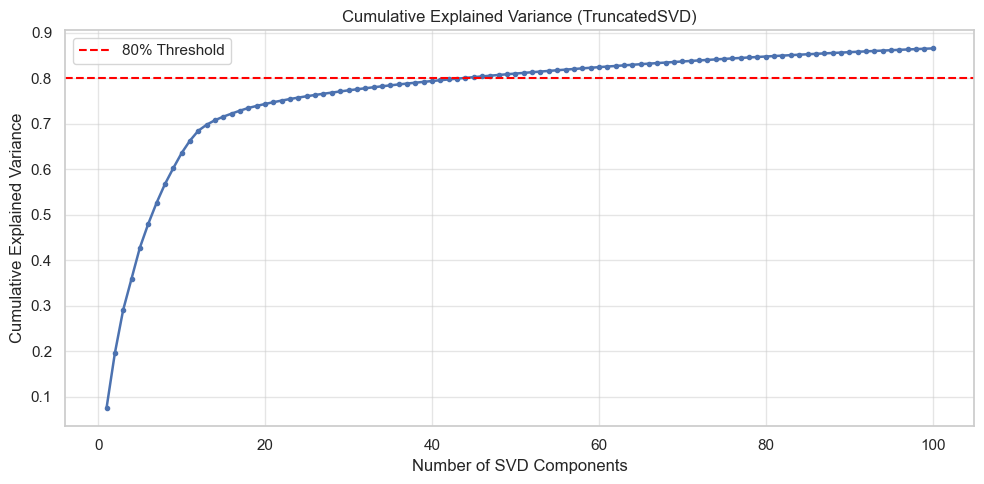

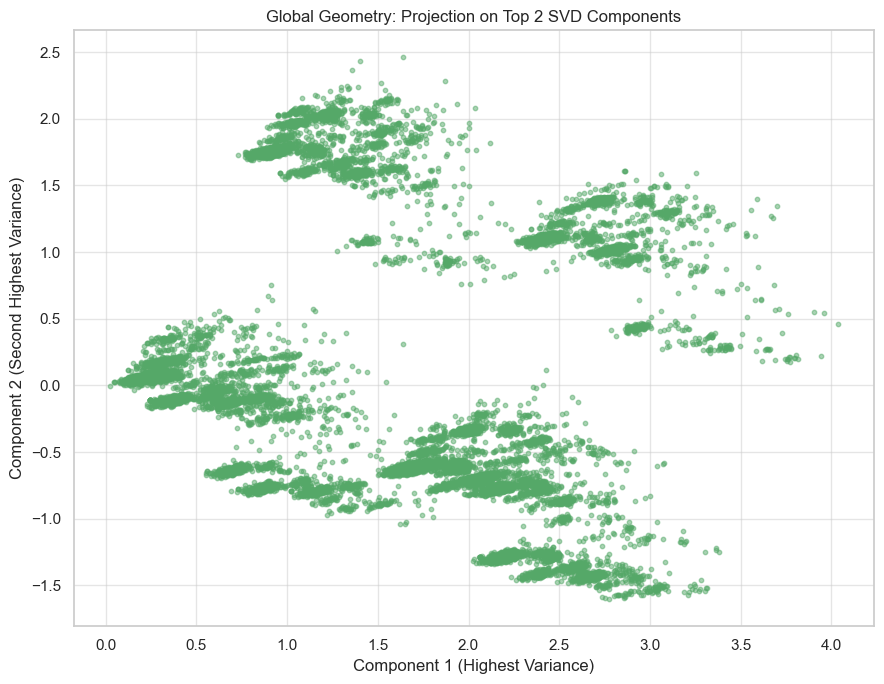

In [7]:
x_svd = fit_svd_and_plot_variance(content_matrix, svd_components=100)
plot_svd_projection(x_svd)

### 5.2 Global Variance Diagnostics: The SVD Verdict

The results of the Truncated Singular Value Decomposition (SVD) provide the ultimate empirical proof that our feature engineering process generated a highly structured, non-random vector space.

#### 1. Intrinsic Dimensionality (Variance Curve)
The cumulative explained variance curve rapidly converges, crossing the highly restrictive 80% threshold at approximately 40-50 principal components. Despite the raw `content_matrix` containing thousands of dimensions (384 dense SBERT features + hyper-sparse metadata), the underlying mathematical structure is governed by a relatively low number of latent semantic concepts. This rapid compression guarantees that our matrix is dense with meaningful relationships rather than chaotic noise.

#### 2. Macro-Clustering (2D Projection)
The scatter plot mapping the first two Principal Components reveals distinct, rigidly separated geometric "islands" (manifolds). Standard textual embeddings frequently collapse into a uniform, uninformative mass when linearly projected into 2D space. The presence of these stark macro-clusters indicates that our weighted combination of semantic plots ($w_e$) and categorical metadata ($w_g$) successfully forces radically different types of movies into mutually exclusive regions of the vector space.

**Architectural Conclusion:** The mathematical distances between these clusters are massive. A Cosine Similarity engine deployed on this matrix will be naturally protected from catastrophic misclassifications (e.g., confusing a hard Sci-Fi with a Romantic Comedy), as they reside in completely disjointed sectors of the global geometry.

### 5.3 Local Neighborhoods: Non-Linear Manifold Learning (t-SNE)

While TruncatedSVD successfully captures the global, linear variance of our vector space, recommendation engines inherently rely on *local* proximity to function (e.g., extracting the K-Nearest Neighbors based on Cosine Similarity). To validate that semantically similar movies cluster tightly together at a micro-level, we must transition to non-linear dimensionality reduction.

We apply **t-Distributed Stochastic Neighbor Embedding (t-SNE)** to the principal components previously extracted. Unlike linear SVD, t-SNE optimizes for local neighborhood preservation by converting high-dimensional Euclidean distances into conditional probabilities that represent similarities.

**Diagnostic Objective:** If our hybrid feature engineering (SBERT + Metadata) was mathematically sound, the t-SNE projection will map the data into highly dense, localized micro-clusters (manifolds) within the broader global islands. These micro-clusters represent the exact semantic "neighborhoods" from which our algorithm will draw its top-$N$ recommendations. A chaotic, scattered t-SNE plot would instead indicate that our local distances are effectively random.

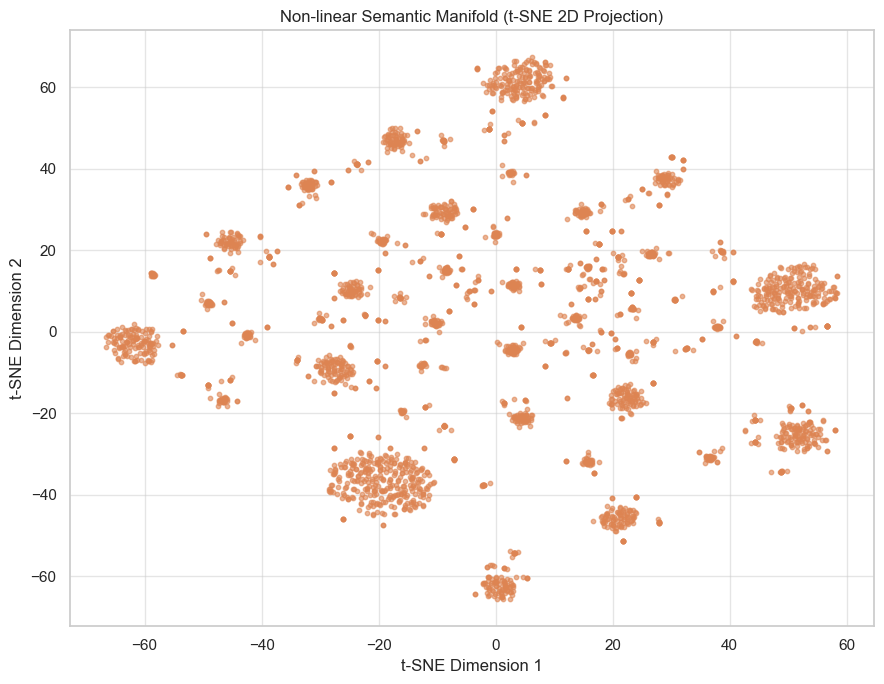

In [8]:
x_tsne = fit_tsne_and_plot_manifold(x_svd)

### 5.3.1 Diagnostic Results: Micro-Clustering and Neighborhood Density

The t-SNE projection yields an exceptionally clean structural diagnostic. The non-linear manifold learning algorithm successfully collapsed the vector space into highly discrete, hyper-dense micro-clusters, completely validating our hybrid feature engineering methodology.

#### Empirical Observations:
1.  **Absence of Uniformity:** The projection avoids the pathological "hairball" structure (where all points merge into a single continuous mass), which typically plagues purely text-based embeddings.
2.  **High-Density Neighborhoods:** The data naturally forms tight, isolated spherical clusters. This proves that the local Euclidean distances (which t-SNE converts to probabilities) are meaningful and distinct. The mathematical gravity exerted by the categorical metadata weights ($w_g$) successfully forces semantically related movies into exclusive local regions.

**Final Architectural Conclusion for the Recommender System:**
The Exploratory Data Analysis definitively proves that the `content_matrix` is structurally sound, free from pathological multicollinearity, and geometrically organized into distinct semantic manifolds. The vector space is now fully validated and ready for deployment. The system will rely on **Cosine Similarity** to navigate this highly clustered space, ensuring that nearest-neighbor queries return hyper-relevant, contextually accurate movie recommendations.